In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from statsmodels.tsa.arima.model import ARIMA

In [2]:
stocks = {

    "IT": [
        "TCS.NS","INFY.NS","WIPRO.NS","HCLTECH.NS","TECHM.NS",
        "LTIM.NS","MPHASIS.NS","PERSISTENT.NS","COFORGE.NS","LTTS.NS"
    ],

    "BANKING": [
        "HDFCBANK.NS","ICICIBANK.NS","SBIN.NS","KOTAKBANK.NS","AXISBANK.NS",
        "INDUSINDBK.NS","BANKBARODA.NS","PNB.NS","IDFCFIRSTB.NS","FEDERALBNK.NS"
    ],

    "FMCG": [
        "HINDUNILVR.NS","ITC.NS","NESTLEIND.NS","BRITANNIA.NS","DABUR.NS",
        "MARICO.NS","GODREJCP.NS","COLPAL.NS","UBL.NS","TATACONSUM.NS"
    ],

    "PHARMA": [
        "SUNPHARMA.NS","DRREDDY.NS","CIPLA.NS","DIVISLAB.NS","BIOCON.NS",
        "LUPIN.NS","AUROPHARMA.NS","TORNTPHARM.NS","ALKEM.NS","GLENMARK.NS"
    ],

    "AUTO": [
        "MARUTI.NS","TATAMOTORS.NS","M&M.NS","BAJAJ-AUTO.NS","EICHERMOT.NS",
        "HEROMOTOCO.NS","ASHOKLEY.NS","TVSMOTOR.NS","ESCORTS.NS","BALKRISIND.NS"
    ],

    "ENERGY": [
        "RELIANCE.NS","ONGC.NS","POWERGRID.NS","NTPC.NS","COALINDIA.NS",
        "BPCL.NS","IOC.NS","GAIL.NS","ADANIGREEN.NS","ADANIPOWER.NS"
    ],

    "METAL": [
        "TATASTEEL.NS","JSWSTEEL.NS","HINDALCO.NS","VEDL.NS","SAIL.NS",
        "JINDALSTEL.NS","NMDC.NS","MOIL.NS","RATNAMANI.NS","WELCORP.NS"
    ]
}

In [3]:
data = {}

for sector, tickers in stocks.items():
    print(f"Downloading {sector}...")
    
    try:
        df = yf.download(
            tickers,
            period="3y",
            group_by="ticker",
            auto_adjust=True,
            threads=True
        )
        
        sector_df = pd.DataFrame()

        for ticker in tickers:
            try:
                sector_df[ticker] = df[ticker]["Close"]
            except:
                continue

        # Clean data
        sector_df = sector_df.ffill().bfill()

        data[sector] = sector_df
        
    except Exception as e:
        print(f"Error in {sector}: {e}")

print("Download Complete ✅")

[*********************100%***********************]  10 of 10 completed


[*********************100%***********************]  10 of 10 completed


[*********************100%***********************]  10 of 10 completed


[*********************100%***********************]  10 of 10 completed


[**********************80%*************          ]  8 of 10 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
$TATAMOTORS.NS: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")
[*********************100%***********************]  10 of 10 completed

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no price data found  (period=3y) (Yahoo error = "No data found, symbol may be delisted")


[*********************100%***********************]  10 of 10 completed


[*********************100%***********************]  10 of 10 completed

Download Complete ✅


In [4]:
sector_index_df = pd.DataFrame({
    sector: df.mean(axis=1)
    for sector, df in data.items()
})

# View first few rows
sector_index_df.head()

,IT,BANKING,FMCG,PHARMA,AUTO,ENERGY,METAL
Date,,,,,,,
2023-04-24,1800.019305,495.490609,1344.666867,1282.797707,2653.644764,295.205826,460.093722
2023-04-25,1800.564119,497.821069,1352.712997,1290.000858,2659.744075,300.545164,460.630974
2023-04-26,1803.609151,501.224513,1360.672089,1289.990285,2667.960876,299.766182,460.859687
2023-04-27,1858.128581,502.669351,1358.144272,1297.977711,2686.440594,300.128816,462.885854
2023-04-28,1891.759149,504.095970,1374.819333,1313.547762,2708.706429,305.900990,463.118724


In [5]:
returns = sector_index_df.pct_change().dropna()

# Volatility (Risk)
volatility = returns.std() * np.sqrt(252)

# Sharpe Ratio
risk_free_rate = 0.05
sharpe = (returns.mean() * 252 - risk_free_rate) / volatility

# CAGR
years = (sector_index_df.index[-1] - sector_index_df.index[0]).days / 365
cagr = (sector_index_df.iloc[-1] / sector_index_df.iloc[0])**(1/years) - 1

# Combine into one table
summary = pd.DataFrame({
    "CAGR": cagr,
    "Volatility": volatility,
    "Sharpe Ratio": sharpe
})

print(summary.sort_values(by="Sharpe Ratio", ascending=False))

             CAGR  Volatility  Sharpe Ratio
PHARMA   0.273921    0.162613      1.296120
AUTO     0.264464    0.177361      1.159415
METAL    0.237193    0.221622      0.867229
ENERGY   0.179008    0.234568      0.622869
BANKING  0.104439    0.167299      0.392102
IT       0.097142    0.218274      0.314045
FMCG     0.082714    0.147627      0.285319


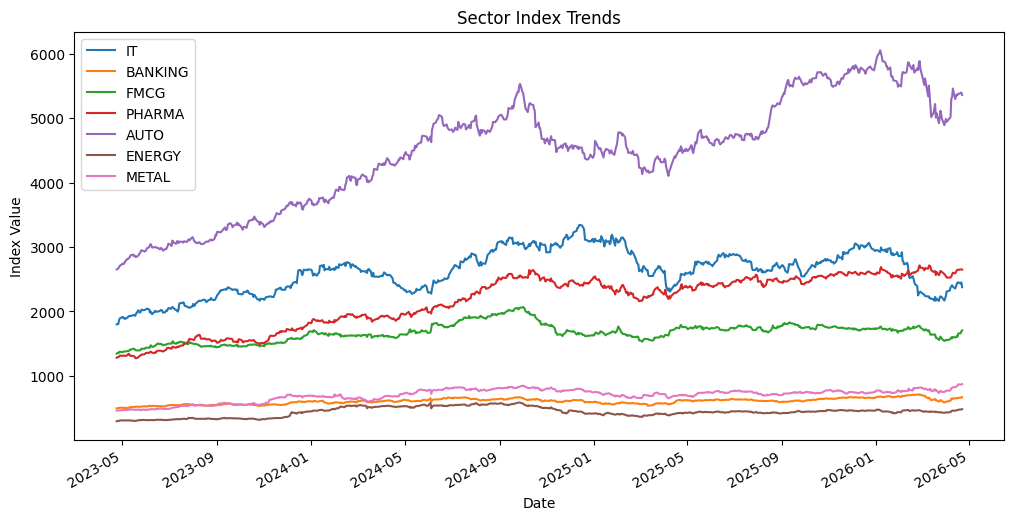

In [6]:
import matplotlib.pyplot as plt

sector_index_df.plot(figsize=(12,6), title="Sector Index Trends")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.show()

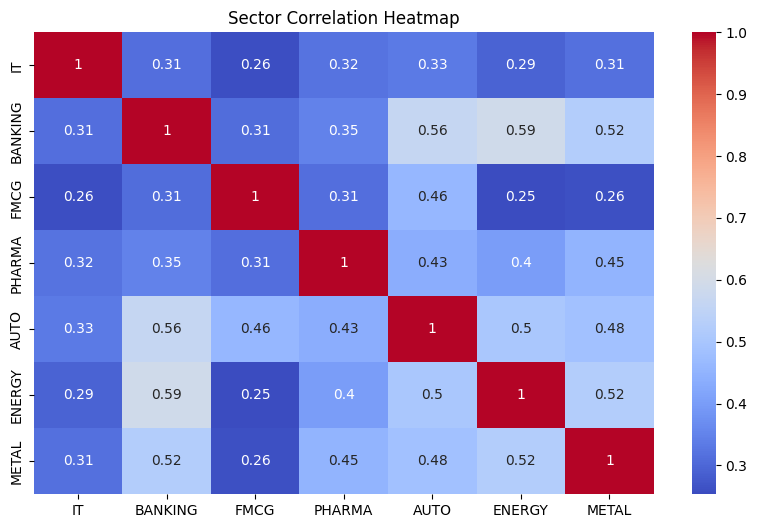

In [7]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm")
plt.title("Sector Correlation Heatmap")
plt.show()

c:\Users\shriv\OneDrive\Desktop\HCL_Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\shriv\OneDrive\Desktop\HCL_Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\shriv\OneDrive\Desktop\HCL_Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\shriv\OneDrive\Desktop\HCL_Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction r

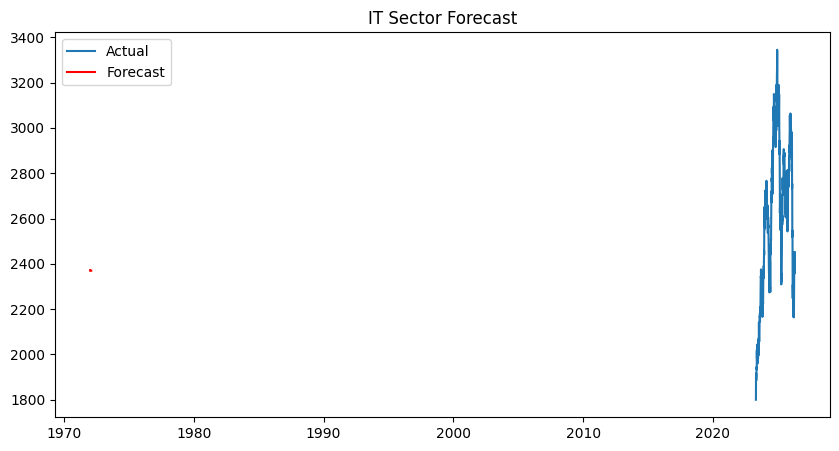

In [8]:
from statsmodels.tsa.arima.model import ARIMA

# Choose one sector (example: IT)
ts_data = sector_index_df["IT"]

model = ARIMA(ts_data, order=(5,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=30)

plt.figure(figsize=(10,5))
plt.plot(ts_data, label="Actual")
plt.plot(forecast, label="Forecast", color='red')
plt.legend()
plt.title("IT Sector Forecast")
plt.show()

In [9]:
import plotly.express as px

df_plot = sector_index_df.reset_index()

fig = px.line(
    df_plot,
    x="Date",
          9     title="Sector Performance Dashboard
    y=df_plot.columns[1:],
    title="Sector Performance Dashboard"
)

fig.show()

SyntaxError: unterminated string literal (detected at line 8) (3282402090.py, line 8)